In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr

df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

df['Mixture'] = df['Mixture'].astype(str).str.strip().str.lower()
df['Species'] = df['Species'].astype(str).str.strip().str.lower()
df['Endpoint'] = df['Endpoint'].astype(str).str.strip().str.lower()

df_filtered = df[
    (df['Mixture'] == 'chemical') &
    (df['Species'] == 'human') &
    (df['Endpoint'] == 'positive reaction')
]

df_filtered = df_filtered.dropna(subset=['Response', 'SMILES']).copy()
df_filtered['Response'] = pd.to_numeric(df_filtered['Response'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Response']).copy()

In [19]:
def standardize_smi(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        mol = rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.FragmentParent(mol)
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

df_filtered['standardized_smi'] = df_filtered['SMILES'].apply(standardize_smi)
df_filtered = df_filtered.dropna(subset=['standardized_smi'])
df_filtered = df_filtered[~df_filtered['standardized_smi'].str.contains(r'\.')]

TH = 10
rows = []
groups = df_filtered.groupby('standardized_smi')

for smi, g in groups:
    y = g['Response'].values
    if len(y) == 1:
        rows.append(g.iloc[0])
    else:
        if (y.max() - y.min()) <= TH:
            r = g.iloc[0].copy()
            r['Response'] = y.mean()
            rows.append(r)

df_dedup = pd.DataFrame(rows).reset_index(drop=True)


[15:42:14] Initializing MetalDisconnector
[15:42:14] Running MetalDisconnector
[15:42:14] Initializing Normalizer
[15:42:14] Running Normalizer
[15:42:14] Initializing MetalDisconnector
[15:42:14] Running MetalDisconnector
[15:42:14] Initializing Normalizer
[15:42:14] Running Normalizer
[15:42:14] Running LargestFragmentChooser
[15:42:14] Initializing MetalDisconnector
[15:42:14] Running MetalDisconnector
[15:42:14] Initializing Normalizer
[15:42:14] Running Normalizer
[15:42:14] Initializing MetalDisconnector
[15:42:14] Running MetalDisconnector
[15:42:14] Initializing Normalizer
[15:42:14] Running Normalizer
[15:42:14] Running LargestFragmentChooser
[15:42:14] Initializing MetalDisconnector
[15:42:14] Running MetalDisconnector
[15:42:14] Initializing Normalizer
[15:42:14] Running Normalizer
[15:42:14] Initializing MetalDisconnector
[15:42:14] Running MetalDisconnector
[15:42:14] Initializing Normalizer
[15:42:14] Running Normalizer
[15:42:14] Running LargestFragmentChooser
[15:42:14]

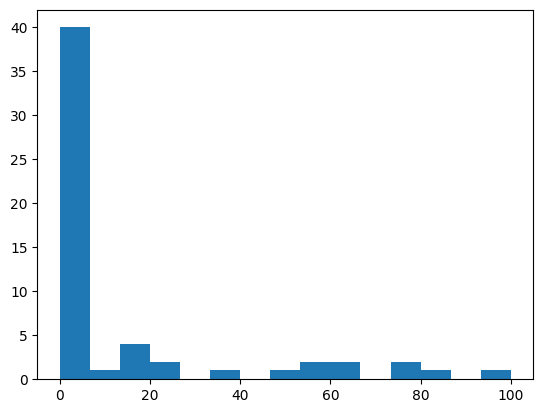

In [20]:
plt.hist(df_dedup['Response'], bins=15)
plt.show()

In [21]:
def to_mol(smi):
    try:
        return Chem.MolFromSmiles(smi)
    except:
        return None

df_dedup['Mol'] = df_dedup['standardized_smi'].apply(to_mol)
df_dedup = df_dedup.dropna(subset=['Mol'])

desc_names = [n for n, _ in Descriptors._descList]

desc_list = []
valid_idx = []

for i, m in df_dedup['Mol'].items():
    try:
        d = Descriptors.CalcMolDescriptors(m)
        desc_list.append(d)
        valid_idx.append(i)
    except:
        pass

df_desc = pd.DataFrame(desc_list, index=valid_idx)

df_model = df_dedup.loc[valid_idx].reset_index(drop=True)
df_model = pd.concat([df_model, df_desc.reset_index(drop=True)], axis=1)

for c in desc_names:
    df_model[c] = pd.to_numeric(df_model[c], errors='coerce')

df_model[desc_names] = df_model[desc_names].replace([np.inf, -np.inf], np.nan)

results = []

In [22]:
for d in desc_names:
    temp = df_model[[d, 'Response']].dropna()
    if temp.shape[0] < 3 or temp[d].nunique() <= 1:
        continue

    X = temp[[d]].values
    y = temp['Response'].values

    m = LinearRegression()
    m.fit(X, y)
    y_pred = m.predict(X)

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    nrmse = rmse / (y.max() - y.min()) if (y.max() - y.min()) != 0 else np.nan
    sp, _ = spearmanr(y, y_pred)
    results.append([d, r2, rmse, mae, nrmse, sp])

In [23]:


res = pd.DataFrame(results, columns=['desc', 'r2', 'rmse', 'mae', 'nrmse', 'spearman'])
res = res.sort_values('r2', ascending=False).reset_index(drop=True)

best = res.iloc[0]['desc']

temp = df_model[[best, 'Response']].dropna()
X = temp[[best]].values
y = temp['Response'].values

m = LinearRegression()
m.fit(X, y)
y_pred = m.predict(X)

print(res.head())
print("Best:", best)
print("R2:", r2_score(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("MAE:", mean_absolute_error(y, y_pred))
print("NRMSE:", np.sqrt(mean_squared_error(y, y_pred)) / (y.max() - y.min()))
print("Spearman:", spearmanr(y, y_pred)[0])

             desc        r2       rmse        mae     nrmse  spearman
0     EState_VSA2  0.132661  23.947374  17.957141  0.239474  0.345202
1            Chi1  0.110223  24.255145  17.458069  0.242551  0.393909
2  HeavyAtomCount  0.109883  24.259786  17.504419  0.242598  0.393363
3       LabuteASA  0.104298  24.335769  17.649476  0.243358  0.379985
4            Chi0  0.102114  24.365431  17.591819  0.243654  0.385220
Best: EState_VSA2
R2: 0.13266082618629282
RMSE: 23.947373825091926
MAE: 17.957140952195417
NRMSE: 0.23947373825091925
Spearman: 0.3452016447716552


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr
import numpy as np

temp = df_model[[best, 'Response']].dropna()

X = temp[[best]].values
y = temp['Response'].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
nrmse = rmse / (y.max() - y.min())
spearman_corr, spearman_p = spearmanr(y, y_pred)

print("Best descriptor:", best)
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)
print("Normalized RMSE:", nrmse)
print("Spearman correlation:", spearman_corr)
print("Spearman p-value:", spearman_p)

Best descriptor: EState_VSA2
R2: 0.13266082618629282
RMSE: 23.947373825091926
MAE: 17.957140952195417
Normalized RMSE: 0.23947373825091925
Spearman correlation: 0.3452016447716552
Spearman p-value: 0.008542113293335492
